In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Which region and advertising channel is the best to invest?

# Data Preprocessing

### Reading data and translating columns to PEP8 

In [2]:
data = pd.read_csv('data.csv')
data.columns = data.columns.str.lower().str.replace(' ', '_')
data.head()

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,social networks,2019-05-01 00:06:40,2019-05-01 00:07:06,26.0,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.0,2019-05-01,5,3,7,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,social networks,2019-05-01 04:30:45,2019-05-01 04:34:56,251.0,2019-05-01,5,3,4,NaN,NaN,NaN,NaN
3,998513020664,United States,iPhone,social networks,2019-05-01 18:53:42,2019-05-01 18:57:35,233.0,2019-05-01,5,3,18,NaN,NaN,NaN,NaN
4,240702200943,United States,Mac,social networks,2019-05-02 14:04:32,2019-05-02 14:09:51,319.0,2019-05-02,5,4,14,NaN,NaN,NaN,NaN


### Initial count of missing values

In [3]:
cols = data.columns
for col in cols:
  missing_count = pd.isna(data[col]).sum().item()
  print(f'{col} - {missing_count} missing values')

user_id - 0 missing values
region - 13 missing values
device - 13 missing values
channel - 13 missing values
session_start - 0 missing values
session_end - 0 missing values
sessiondurationsec - 0 missing values
session_date - 0 missing values
month - 0 missing values
day - 0 missing values
hour_of_day - 0 missing values
order_dt - 727 missing values
revenue - 727 missing values
payment_type - 727 missing values
promo_code - 727 missing values


### Fixing lexical errors

In [4]:
data['region'] = data['region'].replace(['Frаnce', 'Frаncе', 'Franсe'], 'France')
data['region'] = data['region'].replace('Unjted States', 'United States')
data['region'] = data['region'].replace('UК', 'UK')
data['region'] = data['region'].replace('germany', 'Germany')
data['device'] = data['device'].replace('android', 'Android')
data['channel'] = data['channel'].replace('contexual advertising', 'contextual advertising')

### Filling missing values for returning users

In [5]:
pd.set_option('future.no_silent_downcasting', True)
data['region'] = data.groupby('user_id')['region'].transform(lambda x: x.fillna(x.iloc[0]))
data['device'] = data.groupby('user_id')['device'].transform(lambda x: x.fillna(x.iloc[0]))
data['channel'] = data.groupby('user_id')['channel'].transform(lambda x: x.fillna(x.iloc[0]))

### Deleting duplicates

In [6]:
data.drop_duplicates(keep='first', inplace=True)

### Fixing values in promocode column

In [7]:
data = data.drop(data[data['user_id'] == 16254498222].index)

In [8]:
data['promo_code'] = data['promo_code'].apply(lambda x: 0 if 0 < x < 1 else x)
data['sessiondurationsec'] = data['sessiondurationsec'].apply(lambda x: round(x))

### Transfroming columns to datetime

In [9]:
data['session_start'] = pd.to_datetime(data['session_start'])
data['session_end'] = pd.to_datetime(data['session_end'])
data['session_date'] = pd.to_datetime(data['session_date'])
data['order_dt'] = pd.to_datetime(data['order_dt'])

### Research period

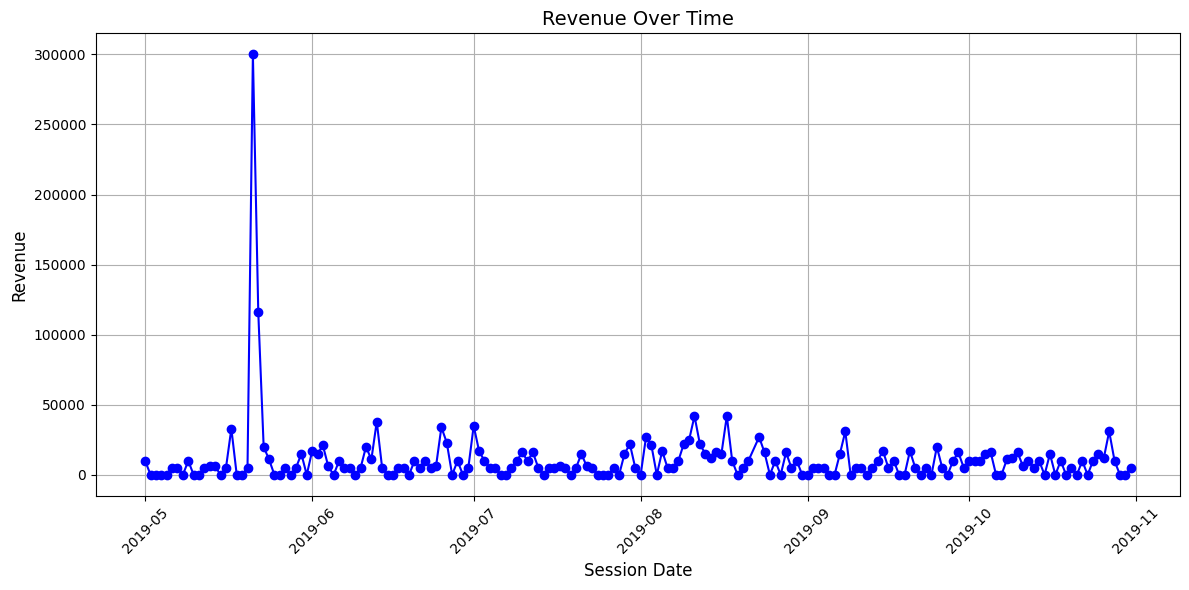

In [10]:
df_plot = data.groupby('session_date')['revenue'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(df_plot['session_date'], df_plot['revenue'], marker='o', linestyle='-', color='b')
plt.title('Revenue Over Time', fontsize=14)
plt.xlabel('Session Date', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Handling outliers

In [11]:
lower_bound = data['revenue'].quantile(0.01)
upper_bound = data['revenue'].quantile(0.98)
m = data['revenue'].median()
data.loc[(data['revenue'] < lower_bound) | (data['revenue'] > upper_bound), 'revenue'] = m

### Final revenue (with promocode)

In [12]:
data['revenue'] = data['revenue'].fillna(0)
data['total_revenue'] = data.apply(
    lambda row: row['revenue'] * 0.9 if row['promo_code'] == 1 else row['revenue'],
    axis=1
)
data['total_revenue'] = data['total_revenue'].fillna(0)

### Adding "time_of_day" column

In [13]:
data['time_of_day'] = data['hour_of_day'].apply(
    lambda x: 'morning' if (x >= 6) and (x < 10) else ('day' if (x >= 10) and (x < 17) else ('evening' if (x >= 17) and (x < 22) else 'night'))
)

### Adding "payer" column

In [14]:
data['payer'] = data.apply(
    lambda x: 1 if (x['total_revenue'] > 0) else 0, axis =1)
data.head(10)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_revenue,time_of_day,payer
0,529697267522,United States,iPhone,social networks,2019-05-01 00:06:40,2019-05-01 00:07:06,26,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0,9999.0,night,1
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782,2019-05-01,5,3,7,NaT,0.0,NaN,NaN,0.0,morning,0
2,852898876338,United States,Mac,social networks,2019-05-01 04:30:45,2019-05-01 04:34:56,251,2019-05-01,5,3,4,NaT,0.0,NaN,NaN,0.0,night,0
3,998513020664,United States,iPhone,social networks,2019-05-01 18:53:42,2019-05-01 18:57:35,233,2019-05-01,5,3,18,NaT,0.0,NaN,NaN,0.0,evening,0
4,240702200943,United States,Mac,social networks,2019-05-02 14:04:32,2019-05-02 14:09:51,319,2019-05-02,5,4,14,NaT,0.0,NaN,NaN,0.0,day,0
5,271758921583,United States,iPhone,social networks,2019-05-02 08:40:35,2019-05-02 08:41:15,40,2019-05-02,5,4,8,NaT,0.0,NaN,NaN,0.0,morning,0
6,425357155257,United States,Android,social networks,2019-05-02 16:32:29,2019-05-02 16:55:30,1381,2019-05-02,5,4,16,NaT,0.0,NaN,NaN,0.0,day,0
7,768721432035,France,Mac,blog advertising,2019-05-02 10:21:30,2019-05-02 10:51:54,1824,2019-05-02,5,4,10,NaT,0.0,NaN,NaN,0.0,day,0
8,177410811849,United States,Android,social networks,2019-05-03 18:43:49,2019-05-03 19:30:52,2823,2019-05-03,5,5,19,NaT,0.0,NaN,NaN,0.0,evening,0
9,337713702816,United States,iPhone,blog advertising,2019-05-03 19:48:35,2019-05-03 20:16:10,1655,2019-05-03,5,5,20,NaT,0.0,NaN,NaN,0.0,evening,0


---

# Analysis and visualization

### Share of sales by region

In [15]:
total = data['total_revenue'].sum()
revenue_by_region = data.groupby('region')['total_revenue'].agg(['sum', 'median']).reset_index()
revenue_by_region['sum_percentage'] = revenue_by_region['sum'].apply(lambda x: str(round(x* 100/total, 2)) + '%')
print(revenue_by_region, '\n')

          region        sum  median sum_percentage
0         France   134874.8     0.0          8.89%
1        Germany   133275.7     0.0          8.79%
2             UK   186766.6     0.0         12.32%
3  United States  1061609.8     0.0          70.0% 



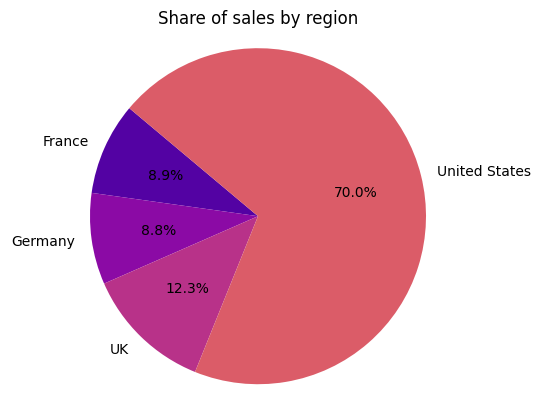

In [16]:
colors = sns.color_palette("plasma")
revenue_by_region = data.groupby('region')['total_revenue'].sum()
plt.pie(revenue_by_region, labels=revenue_by_region.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Share of sales by region')
plt.axis('equal')
plt.show()

### Share of sales by channel

In [17]:
revenue_by_channel = data.groupby('channel')['total_revenue'].agg(['sum', 'median']).reset_index()
revenue_by_channel['sum_percentage'] = revenue_by_channel['sum'].apply(lambda x: str(round(x* 100/total, 2)) + '%')
print(revenue_by_channel, '\n')

                  channel       sum  median sum_percentage
0        blog advertising  156271.3     0.0          10.3%
1  contextual advertising  230156.6     0.0         15.18%
2       email newsletters   36493.3     0.0          2.41%
3                 organic  475814.8     0.0         31.38%
4         social networks  617790.9     0.0         40.74% 



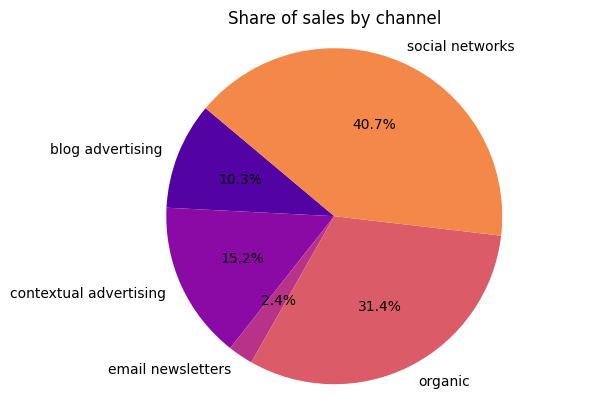

In [18]:
revenue_by_channel = data.groupby('channel')['total_revenue'].sum()
plt.pie(revenue_by_channel, labels=revenue_by_channel.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Share of sales by channel')
plt.axis('equal')
plt.show()

### Share of sales by device

In [19]:
revenue_by_device = data.groupby('device')['total_revenue'].agg(['sum', 'median']).reset_index()
revenue_by_device['sum_percentage'] = revenue_by_device['sum'].apply(lambda x: str(round(x* 100/total, 2)) + '%')
print(revenue_by_device, '\n')

    device       sum  median sum_percentage
0  Android  388429.3     0.0         25.61%
1      Mac  328340.8     0.0         21.65%
2       PC  283149.4     0.0         18.67%
3   iPhone  516607.4     0.0         34.07% 



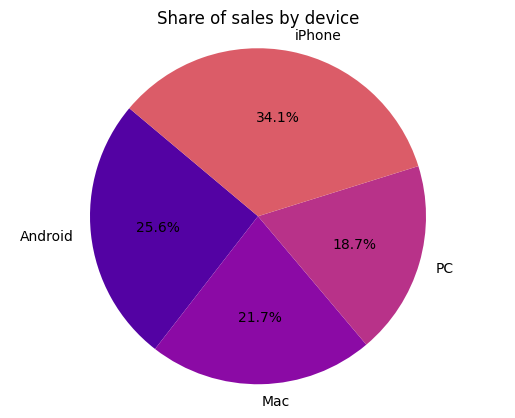

In [20]:
revenue_by_device = data.groupby('device')['total_revenue'].sum()
plt.pie(revenue_by_device, labels=revenue_by_device.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Share of sales by device')
plt.axis('equal')
plt.show()

### Number of payers/not payers by region

In [21]:
payer_by_region = data.groupby(['region', 'payer'])['payer'].value_counts().reset_index()
print(payer_by_region)

          region  payer  count
0         France      0     78
1         France      1     26
2        Germany      0     78
3        Germany      1     25
4             UK      0     83
5             UK      1     34
6  United States      0    488
7  United States      1    196


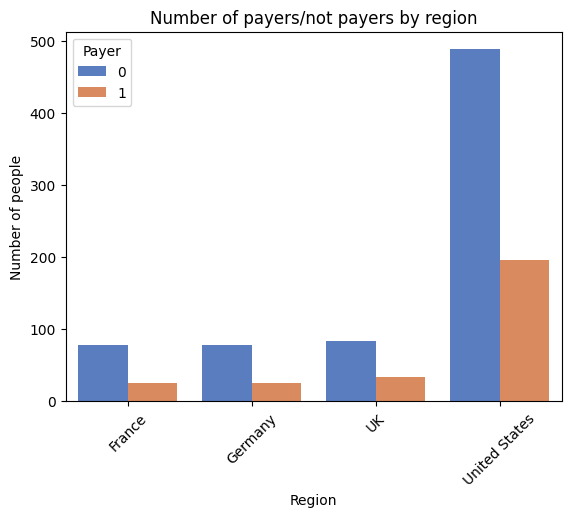

In [22]:
payer_by_region = data.groupby(['region', 'payer'])['payer'].value_counts().reset_index()
sns.barplot(data=payer_by_region, x='region', y='count', hue='payer', palette='muted')
plt.title('Number of payers/not payers by region')
plt.xlabel('Region')
plt.ylabel('Number of people')
plt.xticks(rotation=45)
plt.legend(title='Payer')
plt.show()

### Number of payers/not payers by channel

In [23]:
payer_by_channel = data.groupby(['channel', 'payer'])['payer'].value_counts().reset_index()
print(payer_by_channel)

                  channel  payer  count
0        blog advertising      0     72
1        blog advertising      1     29
2  contextual advertising      0    117
3  contextual advertising      1     45
4       email newsletters      0     17
5       email newsletters      1      7
6                 organic      0    259
7                 organic      1     88
8         social networks      0    262
9         social networks      1    112


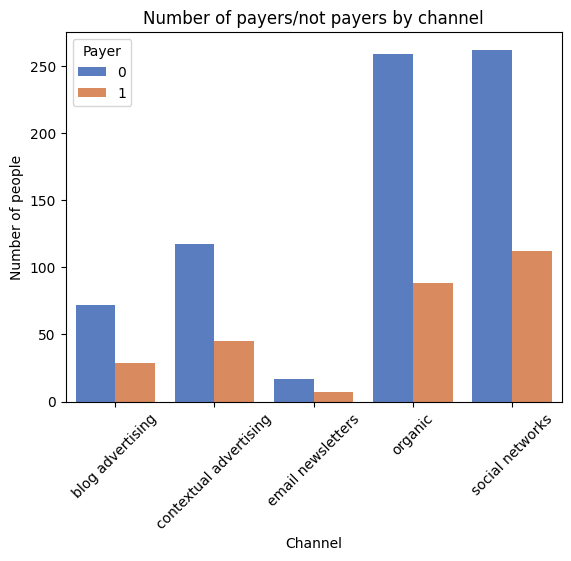

In [24]:
payer_by_channel = data.groupby(['channel', 'payer'])['payer'].value_counts().reset_index()
sns.barplot(data=payer_by_channel, x='channel', y='count', hue='payer', palette='muted')
plt.title('Number of payers/not payers by channel')
plt.xlabel('Channel')
plt.ylabel('Number of people')
plt.xticks(rotation=45)
plt.legend(title='Payer')
plt.show()

### Number of payers/not payers by device

In [25]:
payer_by_device = data.groupby(['device', 'payer'])['payer'].value_counts().reset_index()
print(payer_by_device)

    device  payer  count
0  Android      0    165
1  Android      1     73
2      Mac      0    146
3      Mac      1     61
4       PC      0    155
5       PC      1     52
6   iPhone      0    261
7   iPhone      1     95


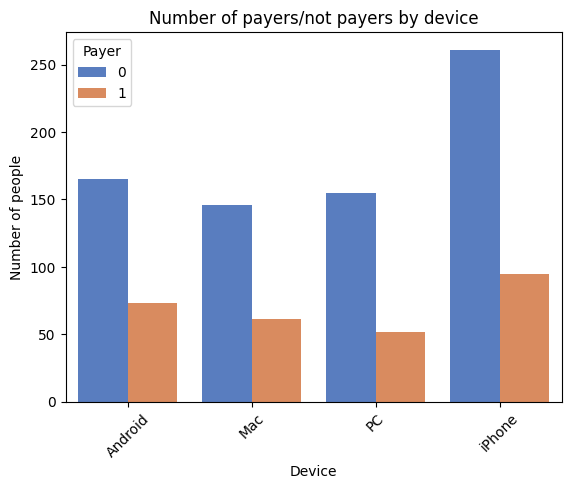

In [26]:
payer_by_device = data.groupby(['device', 'payer'])['payer'].value_counts().reset_index()
sns.barplot(data=payer_by_device, x='device', y='count', hue='payer', palette='muted')
plt.title('Number of payers/not payers by device')
plt.xlabel('Device')
plt.ylabel('Number of people')
plt.xticks(rotation=45)
plt.legend(title='Payer')
plt.show()

### Seasonality in sales by month, day of the week, time of day

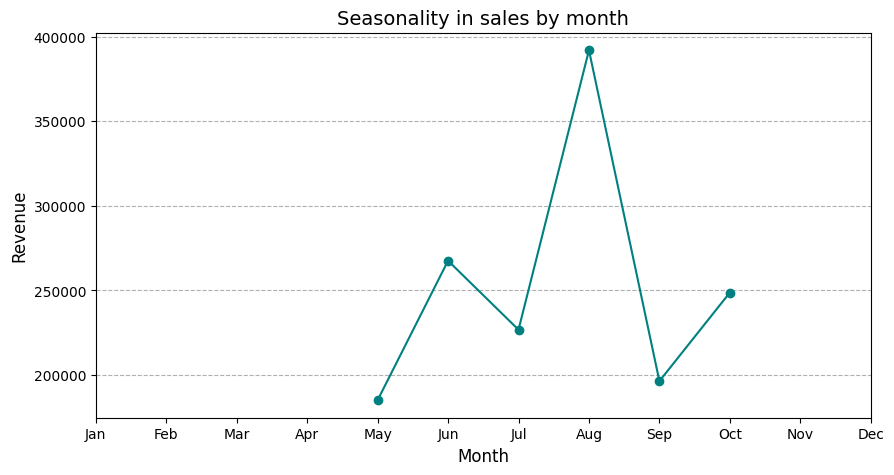

In [27]:
monthly_revenue = data.groupby('month')['total_revenue'].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], marker='o', color='teal')
plt.title('Seasonality in sales by month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--')
plt.show()

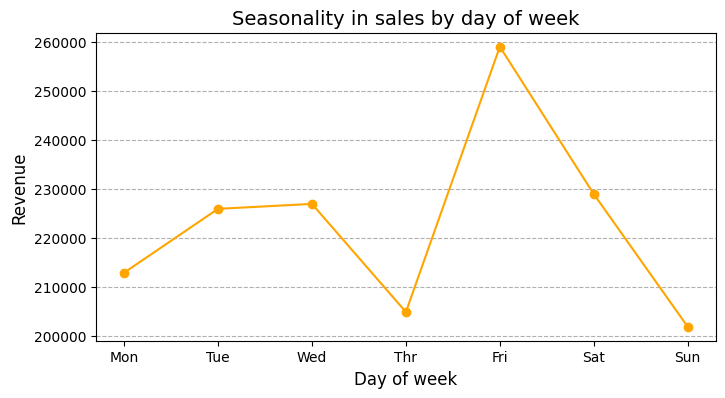

In [28]:
weekday_revenue = data.groupby('day')['revenue'].sum().reset_index()
plt.figure(figsize=(8, 4))
plt.plot(weekday_revenue['day'], weekday_revenue['revenue'], marker='o', color='orange')
plt.title('Seasonality in sales by day of week', fontsize=14)
plt.xlabel('Day of week', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(range(1, 8), labels=['Mon', 'Tue', 'Wed', 'Thr', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--')
plt.show()

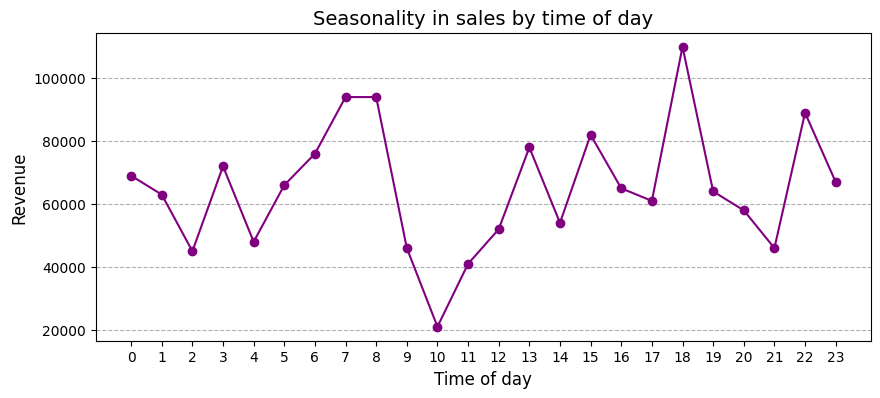

In [29]:
hourly_revenue = data.groupby('hour_of_day')['revenue'].sum().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(hourly_revenue['hour_of_day'], hourly_revenue['revenue'], marker='o', color='purple')
plt.title('Seasonality in sales by time of day', fontsize=14)
plt.xlabel('Time of day', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--')
plt.show()

### Number of purchases by payment type

In [30]:
payment_type_counts = data['payment_type'].value_counts().reset_index()
print(payment_type_counts)

      payment_type  count
0  Mobile payments     85
1         E-wallet     66
2             Cash     60
3       Debit card     36
4      Credit card     34


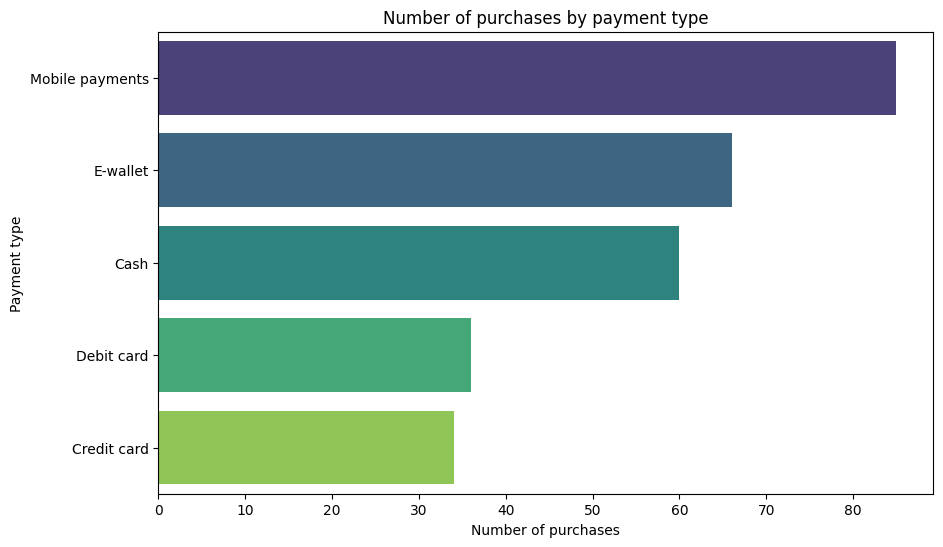

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_type_counts, y='payment_type', x='count', hue='payment_type', palette='viridis')
plt.title('Number of purchases by payment type')
plt.xlabel('Number of purchases')
plt.ylabel('Payment type')
plt.show()

---

# Calculations

### Average receipt

In [32]:
avg_receipt = data['total_revenue'].mean()
print(f"Average receipt: {avg_receipt:.2f}")

Average receipt: 1504.49


### How many purchases does 1 user make on average?

In [33]:
payer_count = data.groupby('user_id')['payer'].sum().reset_index()
print("Average number of purchases of 1 user:", round(payer_count['payer'].mean(), 5))

Average number of purchases of 1 user: 0.28185


### Average session duration by advertising channels

In [34]:
avg_sessiondur_by_channel = data.groupby('channel')['sessiondurationsec'].mean().reset_index()
avg_sessiondur_by_channel['sessiondurationsec'] = avg_sessiondur_by_channel['sessiondurationsec'].apply(lambda x: round(x, 2))
print(avg_sessiondur_by_channel)

                  channel  sessiondurationsec
0        blog advertising             1861.45
1  contextual advertising             1960.79
2       email newsletters             1982.12
3                 organic             1873.38
4         social networks             1694.59


### Average session duration by device

In [35]:
avg_sessiondur_by_device = data.groupby('device')['sessiondurationsec'].mean().reset_index()
avg_sessiondur_by_device['sessiondurationsec'] = avg_sessiondur_by_device['sessiondurationsec'].apply(lambda x: round(x, 2))
print(avg_sessiondur_by_device)

    device  sessiondurationsec
0  Android             1914.04
1      Mac             1773.43
2       PC             1934.10
3   iPhone             1724.90


### Top-3 advertising channels by average receipt

In [36]:
avg_total_revenue_by_channel = (
    data.groupby('channel')['total_revenue']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
avg_total_revenue_by_channel = avg_total_revenue_by_channel.reset_index(drop=True)
avg_total_revenue_by_channel.index = avg_total_revenue_by_channel.index + 1
avg_total_revenue_by_channel.head(3)

,channel,total_revenue
1,social networks,1651.85
2,blog advertising,1547.24
3,email newsletters,1520.55


### Top-3 regions by average receipt

In [37]:
avg_total_revenue_by_channel = (
    data.groupby('region')['total_revenue']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
avg_total_revenue_by_channel = avg_total_revenue_by_channel.reset_index(drop=True)
avg_total_revenue_by_channel.index = avg_total_revenue_by_channel.index + 1
avg_total_revenue_by_channel.head(3)

,region,total_revenue
1,UK,1596.30
2,United States,1552.06
3,France,1296.87


### Top-3 months by average receipt, broken down by region

In [38]:
avg_total_revenue_by_month_region = (
    data.groupby(['region', 'month'])['total_revenue']
    .mean()
    .round(2)
    .reset_index()
)

top_3_months_by_region = (
    avg_total_revenue_by_month_region
    .sort_values(['region', 'total_revenue'], ascending=[True, False])
    .groupby('region')
    .head(3)
    .reset_index(drop=True)
)

top3_channels = top_3_months_by_region.set_index(['region', 'month'])
print(top3_channels)

                     total_revenue
region        month               
France        6            2264.30
              10           1549.71
              5            1229.19
Germany       8            2244.57
              6            1352.15
              5            1166.43
UK            8            2240.34
              6            1941.75
              10           1926.96
United States 8            2133.23
              7            1755.01
              6            1688.36


### Calculate the MAU for each month by advertising channel and select the top 3 advertising channels by the number of unique users per month

In [39]:
mau_by_channel = (
    data.groupby(['month', 'channel'])['user_id']
    .nunique()
    .reset_index(name='mau')
)

top3_channels = (
    mau_by_channel
    .sort_values(['month', 'mau'], ascending=[True, False])
    .groupby('month')
    .head(3)
)

top3_channels = top3_channels.set_index(['month', 'channel'])

print(top3_channels)

                              mau
month channel                    
5     organic                  76
      social networks          41
      blog advertising         14
6     organic                  59
      social networks          53
      contextual advertising   28
7     social networks          57
      organic                  46
      contextual advertising   24
8     social networks          68
      organic                  61
      contextual advertising   37
9     social networks          67
      organic                  58
      contextual advertising   38
10    social networks          85
      organic                  47
      contextual advertising   27


### Create a table in which by advertising channels will be indicated: the number of users, the number of unique users, the number of paying usersand the amount of sales
### Determine which source brought the most paying users and the largest amount of sales

In [40]:
channels_info = data.groupby('channel').agg(
    total_users=('user_id', 'count'),
    unique_users=('user_id', 'nunique'),
    paying_users=('payer', 'sum'),
    total_sales=('total_revenue', 'sum')
).reset_index()

max_payers = channels_info.loc[channels_info['paying_users'].idxmax()].values[0]
max_sales = channels_info.loc[channels_info['total_sales'].idxmax()].values[0]

print(channels_info)
print('\nChannel with max number of payers -', max_payers)
print('Channel with max sales -', max_sales)

                  channel  total_users  unique_users  paying_users  \
0        blog advertising          101           100            29   
1  contextual advertising          162           159            45   
2       email newsletters           24            23             7   
3                 organic          347           346            88   
4         social networks          374           369           112   

   total_sales  
0     156271.3  
1     230156.6  
2      36493.3  
3     475814.8  
4     617790.9  

Channel with max number of payers - social networks
Channel with max sales - social networks


# Hypothesis testing

In [41]:
from scipy.stats import mannwhitneyu, ttest_ind, shapiro, spearmanr, kruskal, f_oneway
import warnings
warnings.filterwarnings('ignore')

### Data normality test

In [42]:
def check_normality(data):
    normality_results = {}
    for group, values in data.items():
        if len(values) >= 3:
            stat, p_value = shapiro(values)
            normality_results[group] = p_value
        else:
            normality_results[group] = None
    return normality_results

### Does the type of device affect the number of purchases per day for each region?

    H₀ (Null hypothesis): The number of purchases per day does not depend on the type of device in the region.
    H₁ (Alternative hypothesis): The number of purchases per day depends on the type of device in the region. 

    Device – nominal scale
    Number of purchases per day for each region – quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [43]:
grouped1 = (data.groupby(['region', 'device', 'session_date'])
    .agg({'user_id': 'count'})
    .rename(columns={'user_id': 'sessions'})
    .reset_index()
)
data_by_region_device = {}
for (region, device), group in grouped1.groupby(['region', 'device']):
    data_by_region_device[(region, device)] = group['sessions']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_region_device)

for group, p_value in normality_results.items():
    region, device = group
    print(f"Region {region}, device {device}: p-value = {p_value:.4f}")

Normality check results (p-value):
Region France, device Android: p-value = 0.0000
Region France, device Mac: p-value = 1.0000
Region France, device PC: p-value = 0.0000
Region France, device iPhone: p-value = 0.0000
Region Germany, device Android: p-value = 0.0000
Region Germany, device Mac: p-value = 1.0000
Region Germany, device PC: p-value = 0.0000
Region Germany, device iPhone: p-value = 0.0000
Region UK, device Android: p-value = 0.0000
Region UK, device Mac: p-value = 1.0000
Region UK, device PC: p-value = 0.0000
Region UK, device iPhone: p-value = 0.0000
Region United States, device Android: p-value = 0.0000
Region United States, device Mac: p-value = 0.0000
Region United States, device PC: p-value = 0.0000
Region United States, device iPhone: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [44]:
def test_device_effect_on_purchases(df):    
    print("Hypothesis testing results:")
    for region in df['region'].unique():
        region_data = grouped1[grouped1['region'] == region]
        
        device_groups = [
            region_data[region_data['device'] == device]['sessions']
            for device in region_data['device'].unique()
        ]
        
        stat, p_value = kruskal(*device_groups)
        print(f"Region {region}: p-value = {p_value:.4f}")
        
                
test_device_effect_on_purchases(data)

Hypothesis testing results:
Region United States: p-value = 0.0000
Region France: p-value = 0.8625
Region Germany: p-value = 0.2218
Region UK: p-value = 0.1921


1. Region United States: p-value = 0.0000

    Decision: Reject H₀ because p-value ≤ 0.05
    Conclusion: In the United States region, the number of purchases per day depends on the type of device

2. Region France: p-value = 0.8625

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the France region, the number of purchases per day does not depend on the type of device

3. Region Germany: p-value = 0.2218

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the Germany region, the number of purchases per day does not depend on the type of device

4. Region UK: p-value = 0.1921

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the UK region, the number of purchases per day does not depend on the type of device

 ------------

### Does the type of advertising channel affect the number of purchases per day for each region?

    H₀ (Null hypothesis): The number of purchases per day does not depend on the type of advertising channel in the region.
    H₁ (Alternative hypothesis): The number of purchases per day depends on the type of advertising channel in the region. 

    Channel – nominal scale
    Number of purchases per day for each region – quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [45]:
grouped2 = (
    data.groupby(['region', 'channel', 'session_date'])
    .agg({'user_id': 'count'})
    .rename(columns={'user_id': 'sessions'})
    .reset_index()
)

data_by_region_channel = {}
for (region, channel), group in grouped2.groupby(['region', 'channel']):
    data_by_region_channel[(region, channel)] = group['sessions']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_region_channel)

for group, p_value in normality_results.items():
    region, channel = group
    print(f"Region {region}, channel {channel}: p-value = {p_value:.4f}")
    

Normality check results (p-value):
Region France, channel blog advertising: p-value = 0.0000
Region France, channel contextual advertising: p-value = 0.0000
Region France, channel email newsletters: p-value = 0.0000
Region France, channel organic: p-value = 0.0000
Region Germany, channel blog advertising: p-value = 1.0000
Region Germany, channel contextual advertising: p-value = 0.0000
Region Germany, channel email newsletters: p-value = 1.0000
Region Germany, channel organic: p-value = 0.0000
Region UK, channel blog advertising: p-value = 0.0000
Region UK, channel contextual advertising: p-value = 0.0000
Region UK, channel email newsletters: p-value = 1.0000
Region UK, channel organic: p-value = 0.0000
Region United States, channel blog advertising: p-value = 0.0000
Region United States, channel contextual advertising: p-value = 0.0000
Region United States, channel organic: p-value = 0.0000
Region United States, channel social networks: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [46]:
def test_channel_effect_on_purchases(df):    
    print("Hypothesis testing results:")
    for region in df['region'].unique():
        region_data = grouped2[grouped2['region'] == region]

        channel_groups = [
            region_data[region_data['channel'] == channel]['sessions']
            for channel in region_data['channel'].unique()
        ]
        
        stat, p_value = kruskal(*channel_groups)
        print(f"Region {region}: p-value = {p_value:.4f}")


test_channel_effect_on_purchases(data)

Hypothesis testing results:
Region United States: p-value = 0.0000
Region France: p-value = 0.5260
Region Germany: p-value = 0.2164
Region UK: p-value = 0.1721


1. Region United States: p-value = 0.0000

    Decision: Reject H₀ because p-value ≤ 0.05
    Conclusion: In the United States region, the number of purchases per day depends on the type of advertising channel

2. Region France: p-value = 0.5260

    Decision: Do not reject H₀ because p-value ≤ 0.05
    Conclusion: In the France region, the number of purchases per day does not depend on the type of advertising channel

3. Region Germany: p-value = 0.2164

    Decision: Do not reject H₀ because p-value ≤ 0.05
    Conclusion: In the Germany region, the number of purchases per day does not depend on the type of advertising channel

4. Region UK: p-value = 0.1721

    Decision: Do not reject H₀ because p-value ≤ 0.05
    Conclusion: In the UK region, the number of purchases per day does not depend on the type of advertising channel

---

### Is there a relationship between the session duration and the purchases amount?

    H₀ (null hypothesis): The purchase amount does not depend on session duration.
    H₁ (alternative hypothesis): The purchase amount depends on session duration.

    Sessiondurationsec - quantitative scale
    Revenue - quantitative scale
    Use either Pearson correlation or Spearman correlation.

Normality check

In [47]:
normality = {'sessiondurationsec': data['sessiondurationsec'], 'revenue': data['revenue']}

print("Normality check results (p-value):")
normality_results = check_normality(normality)

for group, p_value in normality_results.items():
    print(f"Column {group}: p-value = {p_value:.4f}")

Normality check results (p-value):
Column sessiondurationsec: p-value = 0.0000
Column revenue: p-value = 0.0000


The data is non-normal, therefore use the **Spearman correlation**.

In [48]:
stat, p_value = spearmanr(data['sessiondurationsec'], data['revenue'])
print(f"Test statistic: {stat:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between session duration and purchase amount")
else:
    print("Conclusion: There is no statistically significant relationship between session duration and purchase amount")

# plot = data.boxplot(column='revenue', by='region', figsize=(10,6))

Test statistic: 0.0301, p-value: 0.3394
Conclusion: There is no statistically significant relationship between session duration and purchase amount


    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: Purchase amount does not depend on session duration

---

### Does the average receipt vary by region?

    H₀ (null hypothesis): The average receipt does not depend on the region.
    H₁ (alternative hypothesis): The average receipt depends on the region.

    Region - nominal scale
    Revenue - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [49]:
grouped3 = data.groupby('region')['revenue']
normality = {x: group for x, group in grouped3}

print("Normality check results (p-value):")
normality_results = check_normality(normality)

for region, p_value in normality_results.items():
    print(f"Region {region}: p-value = {p_value:.4f}")

Normality check results (p-value):
Region France: p-value = 0.0000
Region Germany: p-value = 0.0000
Region UK: p-value = 0.0000
Region United States: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [50]:
groups = [group for x, group in grouped3]

stat, p_value = kruskal(*groups)

print(f"Test statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The average receipt differs statistically significantly depending on the region.")
else:
    print("Conclusion: The average receipt does not differ statistically significantly depending on the region.")


Test statistic: 1.2801, p-value: 0.7339
Conclusion: The average receipt does not differ statistically significantly depending on the region.


    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: Average receipt does not depend on region

---

### Does the average receipt differ depending on the advertising channel?

    H₀ (null hypothesis): The average receipt does not depend on the advertising channel.
    H₁ (alternative hypothesis): The average receipt depends on the advertising channel.

    Channel - nominal scale
    Revenue - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [51]:
channel_revenue = data.groupby('channel')['revenue']
channels = data['channel'].unique()
normality = {channel: data[data['channel'] == channel]['revenue'] for channel in channels}

print("Normality check results (p-value):")
normality_results = check_normality(normality)

for channel, p_value in normality_results.items():
    print(f"Channel {channel}: p-value = {p_value:.4f}")

Normality check results (p-value):
Channel social networks: p-value = 0.0000
Channel organic: p-value = 0.0000
Channel blog advertising: p-value = 0.0000
Channel contextual advertising: p-value = 0.0000
Channel email newsletters: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [52]:
channel_revenue_data = [data[data['channel'] == channel]['revenue'] for channel in channels]
stat, p_value = kruskal(*channel_revenue_data)

print(f"Test statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: The average receipt differs statistically significantly depending on the region.")
else:
    print("Conclusion: There are no statistically significant differences in the average receipt depending on the channel.")


Test statistic: 2.0590, p-value: 0.7249
Conclusion: There are no statistically significant differences in the average receipt depending on the channel.


    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: Average receipt does not depend on the advertising channel

---

### Does the average receipt vary depending on the time of day?

    H₀ (null hypothesis): The average receipt does not depend on the time of day
    H₁ (alternative hypothesis): The average receipt depends on the time of day

    Time of day - nominal scale
    Revenue - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [53]:
data_by_time = {}
for time_of_day, group in data.groupby('time_of_day'):
    data_by_time[time_of_day] = group['revenue']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_time)

for time_of_day, p_value in normality_results.items():
    print(f"Time of day: {time_of_day}, p-value = {p_value:.4f}")

Normality check results (p-value):
Time of day: day, p-value = 0.0000
Time of day: evening, p-value = 0.0000
Time of day: morning, p-value = 0.0000
Time of day: night, p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [54]:
def test_time_of_day_total_revenue(df):
    print("Hypothesis testing results:")
    groups = [group['revenue'] for x, group in df.groupby('time_of_day')]
    
    stat, p_value = kruskal(*groups)
    print(f"Kruskal–Wallis: p-value = {p_value:.4f}")


test_time_of_day_total_revenue(data)

Hypothesis testing results:
Kruskal–Wallis: p-value = 0.7545


    Decision: Do not reject H₀ because p-value > 0.05
    Вывод: The avearge receipt does not depend on the time of day

---

### Does the type of advertising channel affect the amount of purchases for each region?

    H₀ (null hypothesis): The purchase amount does not depend on the type of advertising channel in the region.
    H₁ (alternative hypothesis): The purchase amount depends on the type of advertising channel in the region.

    Сhannel - nominal scale
    Purchase amount by region - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [55]:
data_by_region_channel = {}
for (region, channel), group in data.groupby(['region', 'channel']):
    data_by_region_channel[(region, channel)] = group['revenue']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_region_channel)
for (region, channel), p_value in normality_results.items():
    print(f"Region {region}, channel {channel}: p-value = {p_value:.4f}")

Normality check results (p-value):
Region France, channel blog advertising: p-value = 0.0000
Region France, channel contextual advertising: p-value = 0.0000
Region France, channel email newsletters: p-value = 0.0002
Region France, channel organic: p-value = 0.0000
Region Germany, channel blog advertising: p-value = 0.0000
Region Germany, channel contextual advertising: p-value = 0.0000
Region Germany, channel email newsletters: p-value = 0.0001
Region Germany, channel organic: p-value = 0.0000
Region UK, channel blog advertising: p-value = 0.0000
Region UK, channel contextual advertising: p-value = 0.0000
Region UK, channel email newsletters: p-value = 0.0003
Region UK, channel organic: p-value = 0.0000
Region United States, channel blog advertising: p-value = 0.0000
Region United States, channel contextual advertising: p-value = 0.0000
Region United States, channel organic: p-value = 0.0000
Region United States, channel social networks: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [56]:
def test_channel_effect_on_total_revenue(df):
    regions = df['region'].unique()
    channels = df['channel'].unique()
    print("Hypothesis testing results:")
    for region in regions:
        region_data = df[df['region'] == region]
        channel_groups = [region_data[region_data['channel'] == channel]['revenue'] for channel in region_data['channel'].unique()]

        stat, p_value = kruskal(*channel_groups)
        print(f"Region {region}: p-value = {p_value:.4f}")
        
        
test_channel_effect_on_total_revenue(data)

Hypothesis testing results:
Region United States: p-value = 0.8035
Region France: p-value = 0.1662
Region Germany: p-value = 0.8702
Region UK: p-value = 0.9523


1. Region United States: p-value = 0.8035

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the United States region, the purchase amount does not depend on the type of channel

2. Region France: p-value = 0.1662

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the France region, the purchase amount does not depend on the type of channel

3. Region Germany: p-value = 0.8702

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the Germany region, the purchase amount does not depend on the type of channel.

4. Region UK: p-value = 0.9523

    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: In the UK region, the purchase amount does not depend on the type of channel.

---

### Does the type of device affect the amount of purchases for each region?

    H₀ (null hypothesis): The purchase amount does not depend on the type of device in the region 
    H₁ (alternative hypothesis): The purchase amount depends on the type of device in the region 

    Device - nominal scale
    Purchase amount by region - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [57]:
data_by_region_device = {}
for (region, device), group in data.groupby(['region', 'device']):
    data_by_region_device[(region, device)] = group['revenue']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_region_device)
for (region, device), p_value in normality_results.items():
    print(f"Region {region}, channel {device}: p-value = {p_value:.4f}")

Normality check results (p-value):
Region France, channel Android: p-value = 0.0000
Region France, channel Mac: p-value = 0.0002
Region France, channel PC: p-value = 0.0000
Region France, channel iPhone: p-value = 0.0000
Region Germany, channel Android: p-value = 0.0000
Region Germany, channel Mac: p-value = 0.0000
Region Germany, channel PC: p-value = 0.0000
Region Germany, channel iPhone: p-value = 0.0000
Region UK, channel Android: p-value = 0.0000
Region UK, channel Mac: p-value = 0.0003
Region UK, channel PC: p-value = 0.0000
Region UK, channel iPhone: p-value = 0.0000
Region United States, channel Android: p-value = 0.0000
Region United States, channel Mac: p-value = 0.0000
Region United States, channel PC: p-value = 0.0000
Region United States, channel iPhone: p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [58]:
def test_device_effect_on_total_revenue(df):
    regions = df['region'].unique()
    devices = df['device'].unique()
    print("Hypothesis testing results:")
    for region in regions:
        region_data = df[df['region'] == region]
        device_groups = [region_data[region_data['device'] == device]['revenue'] for device in region_data['device'].unique()]

        stat, p_value = kruskal(*device_groups)
        print(f"Region {region}: p-value = {p_value:.4f}")
        
        
test_device_effect_on_total_revenue(data)

Hypothesis testing results:
Region United States: p-value = 0.6596
Region France: p-value = 0.2102
Region Germany: p-value = 0.6543
Region UK: p-value = 0.5422


1. Region United States: p-value = 0.6596

    Decision: Do not reject H₀ because p-value > 0.05.
    Conclusion: In the United States region, the purchase amount does not depend on the type of device

2. Region France: p-value = 0.2102

    Decision: Do not reject H₀ because p-value > 0.05.
    Conclusion: In the France region, the purchase amount does not depend on the type of device

3. Region Germany: p-value = 0.6543

    Decision: Do not reject H₀ because p-value > 0.05.
    Conclusion: In the Germany region, the purchase amount does not depend on the type of device

4. Region UK: p-value = 0.5422

    Decision: Do not reject H₀ because p-value > 0.05.
    Conclusion: In the UK region, the purchase amount does not depend on the type of device

---

### Does the type of advertising channel affect the session duration?

    H₀ (null hypothesis): Session duration does not depend on the advertising channel
    H₁ (alternative hypothesis): Session duration depends on the advertising channel

    Channel - nominal scale
    Session duration - quantitative scale
    Use either ANOVA or the Kruskal–Wallis test

Normality check

In [59]:
data_by_channel = {}
for channel, group in data.groupby('channel'):
    data_by_channel[channel] = group['sessiondurationsec']

print("Normality check results (p-value):")
normality_results = check_normality(data_by_channel)

for channel, p_value in normality_results.items():
    print(f"Channel: {channel}, p-value = {p_value:.4f}")

Normality check results (p-value):
Channel: blog advertising, p-value = 0.0000
Channel: contextual advertising, p-value = 0.0000
Channel: email newsletters, p-value = 0.0012
Channel: organic, p-value = 0.0000
Channel: social networks, p-value = 0.0000


The data is non-normal, therefore use the **Kruskal–Wallis test**.

In [60]:
def test_channel_effect_on_duration(df):
    print("Hypothesis testing results:")
    groups = [group['sessiondurationsec'] for _, group in df.groupby('channel')]
    
    stat, p_value = kruskal(*groups)
    print(f"Kruskal–Wallis: p-value = {p_value:.4f}")

test_channel_effect_on_duration(data)

Hypothesis testing results:
Kruskal–Wallis: p-value = 0.3979


    Decision: Do not reject H₀ because p-value > 0.05
    Conclusion: Session duration does not depend on the advertising channel

---

# Regression modeling

In [61]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder


def get_ohe(train, categ):
    ohe.fit(train[categ])
    temp_df = pd.DataFrame(data=ohe.transform(train[categ]), columns=ohe.get_feature_names_out())
    data = pd.concat([train.reset_index(drop=True), temp_df], axis=1)
    data = data.drop(columns=categ, axis=1)
    return data

In [62]:
payers_data = data[data['payer'] == 1]

payers_region_month = payers_data.groupby(
    ['region', 'month']
)['user_id'].count().reset_index(name='payers_count')

pivot_region = payers_region_month.pivot(
    index='region', 
    columns='month', 
    values='payers_count'
).fillna(0)

print("1. Number of payers by region and month:")
print(pivot_region)

payers_channel_month = payers_data.groupby(
    ['channel', 'month']
)['user_id'].count().reset_index(name='payers_count')

pivot_channel = payers_channel_month.pivot(
    index='channel', 
    columns='month', 
    values='payers_count'
).fillna(0)

print("\n2. Number of payers by channel and month:")
print(pivot_channel)


1. Number of payers by region and month:
month          5   6   7   8   9   10
region                               
France          4   7   1   4   4   6
Germany         3   5   2   9   4   2
UK              2   7   5  11   2   7
United States  23  30  35  48  28  32

2. Number of payers by channel and month:
month                     5     6     7     8     9     10
channel                                                   
blog advertising         6.0   5.0   4.0   7.0   3.0   4.0
contextual advertising   1.0   9.0   4.0  16.0   7.0   8.0
email newsletters        2.0   1.0   0.0   1.0   1.0   2.0
organic                 13.0  20.0  13.0  24.0  10.0   8.0
social networks         10.0  14.0  22.0  24.0  17.0  25.0


In [63]:
region_data = pivot_region.reset_index().melt(id_vars='region', var_name='month', value_name='payers')
channel_data = pivot_channel.reset_index().melt(id_vars='channel', var_name='month', value_name='payers')

def predict_next_year(data, group_col, months_to_predict=range(11, 25)):  # 11-24 = nov 2020 - dec 2021
    results = {}
    metrics = []
    
    for group in data[group_col].unique():
        group_df = data[data[group_col] == group]
        X = group_df['month'].values.reshape(-1, 1)
        y = group_df['payers'].values
        
        model = LinearRegression()
        model.fit(X, y)
        
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        
        future_months = np.array(months_to_predict).reshape(-1, 1)
        future_pred = model.predict(future_months)
        
        results[group] = dict(zip(months_to_predict, np.round(future_pred).astype(int)))
        
        metrics.append({
            group_col: group,
            'r2_score': round(r2, 3),
            'mae': round(mae, 1),
        })

        metrics_df = pd.DataFrame(metrics)
    
    return pd.DataFrame(results), metrics_df

region_forecast, region_metrics = predict_next_year(region_data, 'region')
print("Forecast by region (November 2019 - December 2020):")
print(region_forecast)
print("\nR² by region:")
print(region_metrics.sort_values('r2_score', ascending=False))

channel_forecast, channel_metrics = predict_next_year(channel_data, 'channel')
print("\nForecast by channel (November 2019 - December 2020):")
print(channel_forecast)
print("\nR² by channel:")
print(channel_metrics.sort_values('r2_score', ascending=False))

Forecast by region (November 2019 - December 2020):
    France  Germany  UK  United States
11       5        4   7             38
12       5        4   8             39
13       5        4   8             41
14       5        4   9             42
15       5        4   9             44
16       5        4  10             45
17       5        4  10             47
18       6        4  10             48
19       6        4  11             50
20       6        4  11             51
21       6        4  12             53
22       6        4  12             54
23       6        4  13             56
24       6        4  13             57

R² by region:
          region  r2_score  mae
3  United States     0.106  5.9
2             UK     0.062  2.4
0         France     0.011  1.4
1        Germany     0.000  1.9

Forecast by channel (November 2019 - December 2020):
    blog advertising  contextual advertising  email newsletters  organic  \
11                 4                      12              

In [64]:
revenue_region_month = payers_data.groupby(
    ['region', 'month']
)['revenue'].sum().reset_index(name='payers_count')

pivot_revenue_region = revenue_region_month.pivot(
    index='region', 
    columns='month', 
    values='payers_count'
).fillna(0)

print("1. Total revenue by region and month:")
print(pivot_revenue_region)

revenue_channel_month = payers_data.groupby(
    ['channel', 'month']
)['revenue'].sum().reset_index(name='payers_count')

pivot_revenue_channel = revenue_channel_month.pivot(
    index='channel', 
    columns='month', 
    values='payers_count'
).fillna(0)

print("\n2. Total revenue by channel and month:")
print(pivot_revenue_channel)


1. Total revenue by region and month:
month                5         6         7         8         9         10
region                                                                   
France          21996.0   38993.0    4999.0   20996.0   19996.0   31994.0
Germany         14997.0   28995.0   14998.0   46991.0   20996.0    9998.0
UK              10998.0   37993.0   25995.0   61989.0    9998.0   42993.0
United States  143977.0  169970.0  186965.0  274952.0  149972.0  168968.0

2. Total revenue by channel and month:
month                        5         6         7         8        9   \
channel                                                                  
blog advertising        36994.0   25995.0   19996.0   37993.0  15997.0   
contextual advertising   4999.0   48991.0   20996.0   87984.0  34993.0   
email newsletters       10998.0    5999.0       0.0    4999.0   4999.0   
organic                 66987.0  115980.0   72987.0  134976.0  51990.0   
social networks         71990.0   

In [65]:
region_data = pivot_revenue_region.reset_index().melt(id_vars='region', var_name='month', value_name='revenue')
channel_data = pivot_revenue_channel.reset_index().melt(id_vars='channel', var_name='month', value_name='revenue')

def predict_next_year(data, group_col, months_to_predict=range(11, 25)):  # 11-24 = nov 2020 - dec 2021
    results = {}
    metrics = []
    
    for group in data[group_col].unique():
        group_df = data[data[group_col] == group]
        X = group_df['month'].values.reshape(-1, 1)
        y = group_df['revenue'].values
        
        model = LinearRegression()
        model.fit(X, y)
        
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        
        future_months = np.array(months_to_predict).reshape(-1, 1)
        future_pred = model.predict(future_months)
        
        results[group] = dict(zip(months_to_predict, np.round(future_pred).astype(int)))
        metrics.append({
            group_col: group,
            'r2_score': round(r2, 3),
            'mae': round(mae, 1),
        })

        metrics_df = pd.DataFrame(metrics)
    
    return pd.DataFrame(results), metrics_df

region_forecast, region_metrics = predict_next_year(region_data, 'region')
print("Forecast by region (November 2019 - December 2020):")
print(region_forecast)
print("\nR² by region:")
print(region_metrics.sort_values('r2_score',ascending=False))

channel_forecast, channel_metrics = predict_next_year(channel_data, 'channel')
print("\nForecast by channel (November 2019 - December 2020):")
print(channel_forecast)
print("\nR² by channel:")
print(channel_metrics.sort_values('r2_score', ascending=False))

Forecast by region (November 2019 - December 2020):
    France  Germany     UK  United States
11   24062    21129  42859         197762
12   24319    20644  46059         202132
13   24576    20158  49258         206502
14   24833    19672  52458         210872
15   25090    19187  55658         215242
16   25347    18701  58857         219612
17   25604    18215  62057         223982
18   25861    17729  65256         228352
19   26118    17244  68456         232722
20   26375    16758  71655         237092
21   26632    16272  74855         241462
22   26889    15787  78054         245832
23   27146    15301  81254         250201
24   27403    14815  84453         254571

R² by region:
          region  r2_score      mae
2             UK     0.089  14397.6
3  United States     0.029  32327.4
1        Germany     0.005   9947.3
0         France     0.002   8135.1

Forecast by channel (November 2019 - December 2020):
    blog advertising  contextual advertising  email newsletters  orga

#### The social media advertising channel has a higher share of sales, and based on the forecast, it can generate more revenue compared to other channels.

#### The United States region has a larger share of sales